# 1.Loading 

### Industrial Park

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import numpy as np
import os

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed) 
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except ImportError:
        pass


seed_everything(54)

In [49]:
file_path = '/mnt/data/raydata/政策-经济-建设/各级别产业园区信息（2025.7更新）/国家级、省级、区县级产业园区数据.xlsx'
park = pd.read_excel(file_path)

In [50]:
def Display(df):
    print(f"Shape: {df.shape}")
    print(df.columns)
    missing_counts = df.isnull().sum()
    unique_counts = df.nunique()
    summary_df = pd.DataFrame({
        'Missing': missing_counts,
        'Unique': unique_counts,
        'Dtype': df.dtypes
    })
    display(summary_df)

    for col in df.columns:
        print(f"【col: {col}】")
        top_5 = df[col].value_counts().head(5)
        
        if top_5.empty:
            print("  (该列全为空或无有效数据)")
        else:
            for val, count in top_5.items():
                print(f"  - {val}: {count} 次")
        print("-" * 40)

In [ ]:
Display(park)

Shape: (104129, 14)
Index(['级别', '产业', '产业园名称', '简介', '位置', '经度', '纬度', '省份', '城市', '区县',
       'Unnamed: 10', '更多数据请关注公众号', 'Unnamed: 12', 'Unnamed: 13'],
      dtype='object')


In [ ]:
trash_columns = ['Unnamed: 10', '更多数据请关注公众号', 'Unnamed: 12','Unnamed: 13']
park.drop(columns=trash_columns, inplace=True)

In [ ]:
print(f"now the columns are {park.columns}")

now the columns are Index(['级别', '产业', '产业园名称', '简介', '位置', '经度', '纬度', '省份', '城市', '区县'], dtype='object')


### Housing price

In [ ]:
housing_path = '/mnt/data/raydata/房产/Housing_Sale_Listing_Rent/community_p/community.parquet'
housing = pd.read_parquet(housing_path)
Display(housing)

Shape: (317229, 28)
Index(['名称', '城市', '区县', '板块', '参考均价', '环线位置', '小区地址', '物业类别', '建筑年代', '开发商',
       '房屋总数', '楼栋总数', '物业公司', '绿 化 率', '容 积 率', '物 业 费', '建筑结构', '物业办公电话',
       '产权描述', '供水', '供暖', '供电', '燃气费', '供热费', '停车位', '停车费用', 'baidu_coord_x',
       'baidu_coord_y'],
      dtype='object')


,Missing,Unique,Dtype
名称,0,278183,object
城市,0,97,object
区县,0,1020,object
板块,1243,5104,object
参考均价,77819,46637,float64
环线位置,263662,32,object
小区地址,12,301569,object
物业类别,9056,1372,object
建筑年代,123145,2603,object
开发商,132682,47763,object


【col: 名称】
  - 阳光花园: 64 次
  - 幸福家园: 63 次
  - 锦绣花园: 59 次
  - 粮食局宿舍: 42 次
  - 和谐家园: 41 次
----------------------------------------
【col: 城市】
  - 上海: 22092 次
  - 成都: 18260 次
  - 北京: 10945 次
  - 重庆: 10104 次
  - 苏州: 8625 次
----------------------------------------
【col: 区县】
  - 浦东: 3659 次
  - 顺德: 2216 次
  - 城关区: 2083 次
  - 鼓楼区: 2011 次
  - 金水: 1893 次
----------------------------------------
【col: 板块】
  - 老城区: 2106 次
  - 火车站: 1624 次
  - 魏都区: 1113 次
  - 都江堰: 1101 次
  - 海城区: 1060 次
----------------------------------------
【col: 参考均价】
  - 60000.0: 57 次
  - 50000.0: 51 次
  - 55000.0: 43 次
  - 68000.0: 41 次
  - 40000.0: 38 次
----------------------------------------
【col: 环线位置】
  - 外环外: 8494 次
  - 内环内: 7878 次
  - 二至三环: 6307 次
  - 内环至中环: 4184 次
  - 中环至外环: 3638 次
----------------------------------------
【col: 小区地址】
  - 兴华中路: 56 次
  - 太极大道: 50 次
  - 浔峰洲路8号: 37 次
  - 顺江大道: 34 次
  - 黎明路: 33 次
----------------------------------------
【col: 物业类别】
  - 普通住宅: 211943 次
  - 普通住宅/底商: 14259 次
  - 普通住宅/别墅: 10379 次
 

# 2.Cleaning & Integration


In [ ]:
# Data Cleaning

park_cleaned = park.dropna(subset=['经度','纬度'])
housing_cleaned = housing.dropna(subset=['baidu_coord_x','baidu_coord_y','参考均价','板块'])
housing_cleaned = housing_cleaned.rename(columns={'baidu_coord_x':'x','baidu_coord_y':'y','参考均价':'price'})
park_cleaned = park_cleaned.rename(columns={'经度':'x','纬度':'y'})

In [ ]:
sub_housing = housing_cleaned.drop(columns=['环线位置','物业办公电话','供热费']).copy()
sub_park = park_cleaned[['x', 'y','产业']].copy()

In [ ]:
# according to the distance to find the nearest park for each community
import numpy as np
from sklearn.neighbors import NearestNeighbors

park_coords_rad = np.radians(sub_park[['x', 'y']])
house_coords_rad = np.radians(sub_housing[['x', 'y']])

model = NearestNeighbors(n_neighbors=1, algorithm='ball_tree', metric='haversine')
model.fit(park_coords_rad)

distances_rad, indices = model.kneighbors(house_coords_rad)

sub_housing['nearest_park_dist_km'] = distances_rad.flatten() * 6371

sub_housing['nearest_park_index'] = sub_park.index[indices.flatten()]

sub_housing['nearest_park_industry'] = sub_park.loc[sub_housing['nearest_park_index'], '产业'].values
print(sub_housing[['x', 'y', 'nearest_park_index', 'nearest_park_dist_km']].head())

             x          y  nearest_park_index  nearest_park_dist_km
1   104.110757  30.686905               11977              0.488280
7   104.113817  30.696091                5638              0.170696
10  104.109100  30.685527               10670              0.365403
11  104.119772  30.693906                5646              0.530374
12  104.113288  30.690898                5638              0.195805


In [ ]:
sub_housing['log_price'] = np.log(sub_housing['price'] + 1)


# 3.Imputation & Encoding

In [ ]:
sub_housing.columns

Index(['名称', '城市', '区县', '板块', 'price', '小区地址', '物业类别', '建筑年代', '开发商', '房屋总数',
       '楼栋总数', '物业公司', '绿 化 率', '容 积 率', '物 业 费', '建筑结构', '产权描述', '供水', '供暖',
       '供电', '燃气费', '停车位', '停车费用', 'x', 'y', 'nearest_park_dist_km',
       'nearest_park_index', 'nearest_park_industry', 'log_price'],
      dtype='object')

In [ ]:
# 城市、区县、板块 ：Embedding Encoding
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder,StandardScaler

city_le = LabelEncoder()
dist_le = LabelEncoder()
neigh_le = LabelEncoder()

sub_housing['city_idx'] = city_le.fit_transform(sub_housing['城市'])
sub_housing['dist_idx'] = dist_le.fit_transform(sub_housing['区县'])
sub_housing['neigh_idx'] = neigh_le.fit_transform(sub_housing['板块'])

n_cities = len(city_le.classes_)   
n_dists = len(dist_le.classes_)
n_neighs = len(neigh_le.classes_)






In [ ]:
city_tensor = torch.tensor(sub_housing['city_idx'].values, dtype=torch.long)
dist_tensor = torch.tensor(sub_housing['dist_idx'].values, dtype=torch.long)
neigh_tensor = torch.tensor(sub_housing['neigh_idx'].values, dtype=torch.long)
target_tensor = torch.tensor(sub_housing['log_price'].values, dtype=torch.float32)

class GeoEmbeddingModel(nn.Module):
    def __init__(self, n_cities, n_dists, n_neighs, city_dim=8, dist_dim=24, neigh_dim=32):
        super().__init__()
        self.city_emb = nn.Embedding(n_cities, city_dim)
        self.dist_emb = nn.Embedding(n_dists, dist_dim)
        self.neigh_emb = nn.Embedding(n_neighs, neigh_dim)
        self.net = nn.Sequential(
            nn.Linear(city_dim + dist_dim + neigh_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.1),
            
            nn.Linear(64, 1)
        )
        
    def forward(self, c_idx, d_idx, n_idx):
        c = self.city_emb(c_idx)
        d = self.dist_emb(d_idx)
        n = self.neigh_emb(n_idx)
        out = torch.cat([c, d, n], dim=1)
        return self.net(out)
    


In [ ]:
model = GeoEmbeddingModel(n_cities, n_dists, n_neighs)
optimizer = optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.MSELoss()

dataset = TensorDataset(city_tensor, dist_tensor, neigh_tensor, target_tensor)
loader = DataLoader(dataset, batch_size=256, shuffle=True)



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import copy 


full_dataset = TensorDataset(city_tensor, dist_tensor, neigh_tensor, target_tensor)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

model = GeoEmbeddingModel(n_cities, n_dists, n_neighs)
optimizer = optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.MSELoss()

epochs = 200 
patience = 10 
best_val_loss = float('inf')
counter = 0
best_model_state = None 

for epoch in range(epochs):
    
    model.train()
    train_loss = 0
    for b_city, b_dist, b_neigh, b_target in train_loader:
        optimizer.zero_grad()
        preds = model(b_city, b_dist, b_neigh)
        loss = criterion(preds, b_target.view(-1, 1)) 
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for b_city, b_dist, b_neigh, b_target in val_loader:
            preds = model(b_city, b_dist, b_neigh)
            loss = criterion(preds, b_target.view(-1, 1))
            val_loss += loss.item()
    
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1
        counter = 0
        print(f"Epoch {epoch+1}: New best model saved! (Val Loss: {avg_val_loss:.4f})")
    else:
        counter += 1
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
        
    if counter >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}. Best Val Loss: {best_val_loss:.4f}")
        break

if best_model_state:
    model.load_state_dict(best_model_state)
    print("Successfully loaded the best model parameters.")

Epoch 1: New best model saved! (Val Loss: 0.7911)
Epoch 2: New best model saved! (Val Loss: 0.4559)
Epoch 3: New best model saved! (Val Loss: 0.3963)
Epoch 4: New best model saved! (Val Loss: 0.3506)
Epoch 7: New best model saved! (Val Loss: 0.3172)
Epoch 8: New best model saved! (Val Loss: 0.3134)
Epoch 9: New best model saved! (Val Loss: 0.2511)
Epoch 10: New best model saved! (Val Loss: 0.2257)
Epoch 11: New best model saved! (Val Loss: 0.1794)
Epoch 12: New best model saved! (Val Loss: 0.1451)
Epoch 14: New best model saved! (Val Loss: 0.1429)
Epoch 15: New best model saved! (Val Loss: 0.1196)
Epoch 16: New best model saved! (Val Loss: 0.1075)
Epoch 17: New best model saved! (Val Loss: 0.1062)
Epoch 20: Train Loss: 0.2526, Val Loss: 0.1122
Epoch 21: New best model saved! (Val Loss: 0.0961)
Epoch 24: New best model saved! (Val Loss: 0.0837)
Epoch 26: New best model saved! (Val Loss: 0.0834)
Epoch 30: Train Loss: 0.1883, Val Loss: 0.0849
Epoch 33: New best model saved! (Val Loss: 0.0

In [ ]:
"""
full_loader = DataLoader(full_dataset, batch_size=256, shuffle=True)

final_model = GeoEmbeddingModel(n_cities, n_dists)
final_optimizer = optim.Adam(final_model.parameters(), lr=0.0005)
final_criterion = nn.MSELoss()

final_model.train()
for epoch in range(best_epoch):
    running_loss = 0.0
    for b_city, b_dist, b_target in full_loader:
        final_optimizer.zero_grad()
        preds = final_model(b_city, b_dist)
        loss = final_criterion(preds, b_target.view(-1, 1))
        loss.backward()
        final_optimizer.step()
        running_loss += loss.item()
    
    if (epoch + 1) % 10 == 0 or (epoch + 1) == best_epoch:
        print(f"Full Training Epoch {epoch+1}/{best_epoch}, Loss: {running_loss/len(full_loader):.4f}")

with torch.no_grad():
    final_city_embeddings = final_model.city_emb.weight.detach().cpu().numpy()
    final_dist_embeddings = final_model.dist_emb.weight.detach().cpu().numpy()"""

'\nfull_loader = DataLoader(full_dataset, batch_size=256, shuffle=True)\n\nfinal_model = GeoEmbeddingModel(n_cities, n_dists)\nfinal_optimizer = optim.Adam(final_model.parameters(), lr=0.0005)\nfinal_criterion = nn.MSELoss()\n\nfinal_model.train()\nfor epoch in range(best_epoch):\n    running_loss = 0.0\n    for b_city, b_dist, b_target in full_loader:\n        final_optimizer.zero_grad()\n        preds = final_model(b_city, b_dist)\n        loss = final_criterion(preds, b_target.view(-1, 1))\n        loss.backward()\n        final_optimizer.step()\n        running_loss += loss.item()\n    \n    if (epoch + 1) % 10 == 0 or (epoch + 1) == best_epoch:\n        print(f"Full Training Epoch {epoch+1}/{best_epoch}, Loss: {running_loss/len(full_loader):.4f}")\n\nwith torch.no_grad():\n    final_city_embeddings = final_model.city_emb.weight.detach().cpu().numpy()\n    final_dist_embeddings = final_model.dist_emb.weight.detach().cpu().numpy()'

In [ ]:
"""print(f"城市 Embedding 形状: {final_city_embeddings.shape}") 
print(f"区县 Embedding 形状: {final_dist_embeddings.shape}") """

'print(f"城市 Embedding 形状: {final_city_embeddings.shape}") \nprint(f"区县 Embedding 形状: {final_dist_embeddings.shape}") '

In [ ]:
city_embeddings_raw = best_model_state['city_emb.weight'].cpu().numpy()
dist_embeddings_raw = best_model_state['dist_emb.weight'].cpu().numpy()
neigh_embeddings_raw = best_model_state['neigh_emb.weight'].cpu().numpy()

print(f"城市 Embedding 形状: {city_embeddings_raw.shape}")
print(f"区县 Embedding 形状: {dist_embeddings_raw.shape}") 
print(f"板块 Embedding 形状: {neigh_embeddings_raw.shape}") 

城市 Embedding 形状: (89, 8)
区县 Embedding 形状: (911, 24)
板块 Embedding 形状: (4719, 32)


In [ ]:
city_col_names = [f'city_v_{i}' for i in range(city_embeddings_raw.shape[1])]
df_city_vectors = pd.DataFrame(city_embeddings_raw, columns=city_col_names)
df_city_vectors['城市'] = city_le.classes_


dist_col_names = [f'dist_v_{i}' for i in range(dist_embeddings_raw.shape[1])]
df_dist_vectors = pd.DataFrame(dist_embeddings_raw, columns=dist_col_names)
df_dist_vectors['区县'] = dist_le.classes_

neigh_col_names = [f'neigh_v_{i}' for i in range(neigh_embeddings_raw.shape[1])]
df_neigh_vectors = pd.DataFrame(neigh_embeddings_raw, columns=neigh_col_names)
df_neigh_vectors['板块'] = neigh_le.classes_

In [ ]:
df = sub_housing.copy()
df = df.merge(df_city_vectors, left_on='城市', right_on='城市', how='left')
df = df.merge(df_dist_vectors, left_on='区县', right_on='区县', how='left')
df = df.merge(df_neigh_vectors, left_on='板块', right_on='板块', how='left')
df.columns

Index(['名称', '城市', '区县', '板块', 'price', '小区地址', '物业类别', '建筑年代', '开发商', '房屋总数',
       '楼栋总数', '物业公司', '绿 化 率', '容 积 率', '物 业 费', '建筑结构', '产权描述', '供水', '供暖',
       '供电', '燃气费', '停车位', '停车费用', 'x', 'y', 'nearest_park_dist_km',
       'nearest_park_index', 'nearest_park_industry', 'log_price', 'city_idx',
       'dist_idx', 'neigh_idx', 'city_v_0', 'city_v_1', 'city_v_2', 'city_v_3',
       'city_v_4', 'city_v_5', 'city_v_6', 'city_v_7', 'dist_v_0', 'dist_v_1',
       'dist_v_2', 'dist_v_3', 'dist_v_4', 'dist_v_5', 'dist_v_6', 'dist_v_7',
       'dist_v_8', 'dist_v_9', 'dist_v_10', 'dist_v_11', 'dist_v_12',
       'dist_v_13', 'dist_v_14', 'dist_v_15', 'dist_v_16', 'dist_v_17',
       'dist_v_18', 'dist_v_19', 'dist_v_20', 'dist_v_21', 'dist_v_22',
       'dist_v_23', 'neigh_v_0', 'neigh_v_1', 'neigh_v_2', 'neigh_v_3',
       'neigh_v_4', 'neigh_v_5', 'neigh_v_6', 'neigh_v_7', 'neigh_v_8',
       'neigh_v_9', 'neigh_v_10', 'neigh_v_11', 'neigh_v_12', 'neigh_v_13',
       'neigh_v_14', 'n

/home/yubo/.conda/envs/Housing/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/yubo/.conda/envs/Housing/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


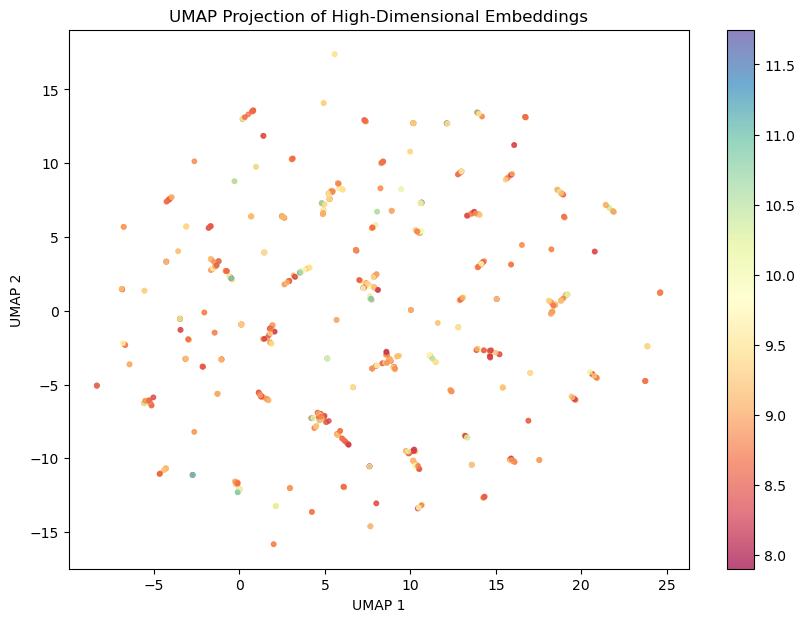

In [ ]:
# visualize the location distribution of embeddings
import umap



reducer = umap.UMAP(
    n_neighbors=2,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

embedding_2d = reducer.fit_transform(dist_embeddings_raw)

dist_stats = sub_housing.groupby('区县')['log_price'].mean().reindex(dist_le.classes_)
labels = dist_stats.values

plt.figure(figsize=(10, 7))
plt.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    c=labels,         
    cmap='Spectral',
    s=10,
    alpha=0.7
)
plt.colorbar()
plt.title('UMAP Projection of High-Dimensional Embeddings')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

/home/yubo/.conda/envs/Housing/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


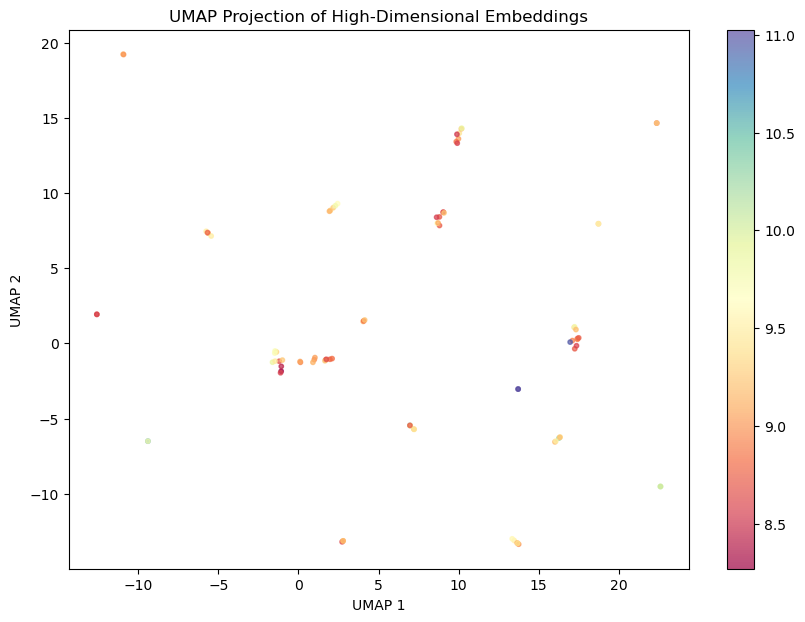

In [ ]:
reducer = umap.UMAP(
    n_neighbors=2,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

embedding_2d = reducer.fit_transform(city_embeddings_raw)

city_stats = sub_housing.groupby('城市')['log_price'].mean().reindex(city_le.classes_)
labels = city_stats.values

plt.figure(figsize=(10, 7))
plt.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    c=labels,         
    cmap='Spectral',
    s=10,
    alpha=0.7
)
plt.colorbar()
plt.title('UMAP Projection of High-Dimensional Embeddings')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

/home/yubo/.conda/envs/Housing/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


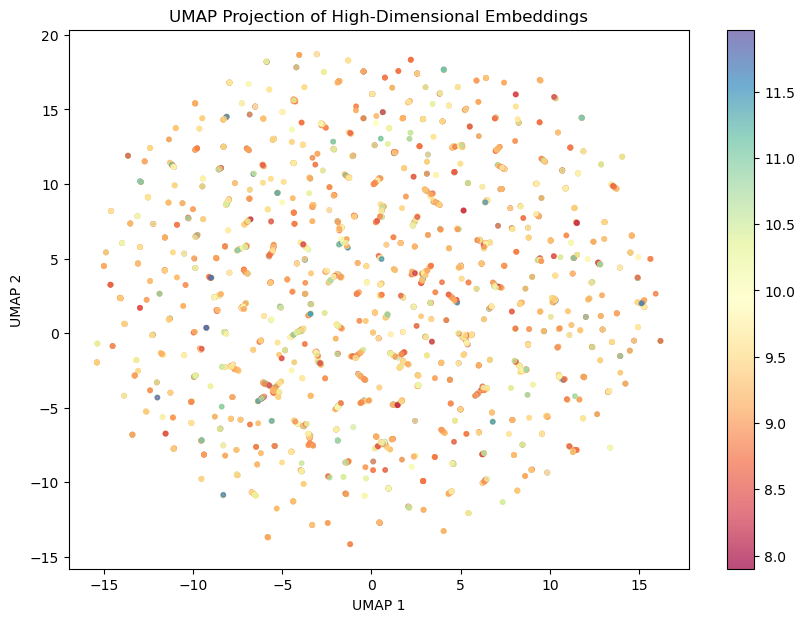

In [ ]:
reducer = umap.UMAP(
    n_neighbors=2,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

embedding_2d = reducer.fit_transform(neigh_embeddings_raw)

neigh_stats = sub_housing.groupby('板块')['log_price'].mean().reindex(neigh_le.classes_)
labels = neigh_stats.values

plt.figure(figsize=(10, 7))
plt.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    c=labels,         
    cmap='Spectral',
    s=10,
    alpha=0.7
)
plt.colorbar()
plt.title('UMAP Projection of High-Dimensional Embeddings')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

In [ ]:
df.columns

Index(['名称', '城市', '区县', '板块', 'price', '小区地址', '物业类别', '建筑年代', '开发商', '房屋总数',
       '楼栋总数', '物业公司', '绿 化 率', '容 积 率', '物 业 费', '建筑结构', '产权描述', '供水', '供暖',
       '供电', '燃气费', '停车位', '停车费用', 'x', 'y', 'nearest_park_dist_km',
       'nearest_park_index', 'nearest_park_industry', 'log_price', 'city_idx',
       'dist_idx', 'neigh_idx', 'city_v_0', 'city_v_1', 'city_v_2', 'city_v_3',
       'city_v_4', 'city_v_5', 'city_v_6', 'city_v_7', 'dist_v_0', 'dist_v_1',
       'dist_v_2', 'dist_v_3', 'dist_v_4', 'dist_v_5', 'dist_v_6', 'dist_v_7',
       'dist_v_8', 'dist_v_9', 'dist_v_10', 'dist_v_11', 'dist_v_12',
       'dist_v_13', 'dist_v_14', 'dist_v_15', 'dist_v_16', 'dist_v_17',
       'dist_v_18', 'dist_v_19', 'dist_v_20', 'dist_v_21', 'dist_v_22',
       'dist_v_23', 'neigh_v_0', 'neigh_v_1', 'neigh_v_2', 'neigh_v_3',
       'neigh_v_4', 'neigh_v_5', 'neigh_v_6', 'neigh_v_7', 'neigh_v_8',
       'neigh_v_9', 'neigh_v_10', 'neigh_v_11', 'neigh_v_12', 'neigh_v_13',
       'neigh_v_14', 'n

### Numerical variables

In [ ]:
import re
def process_price(text):

    if pd.isna(text):
        return None
    nums = re.findall(r"\d+\.?\d*", text)
    nums = [float(n) for n in nums]

    if len(nums) >= 2:
        avg = sum(nums[:2]) / 2
        return avg
    elif len(nums) == 1:
        return nums[0]
    else:
        return None
    
def extract_year(text):
    if pd.isna(text):
        return None
    match = re.search(r'(\d{4})', str(text))
    if match:
        return int(match.group(1))
    return None

In [ ]:
df['房屋总数'] = df['房屋总数'].apply(process_price)
df['楼栋总数'] = df['楼栋总数'].apply(process_price)
df['绿 化 率'] = df['绿 化 率'].apply(process_price)

In [ ]:
df['燃气费'] = df['燃气费'].apply(process_price)
df['物 业 费'] = df['物 业 费'].apply(process_price)
df['建筑年代'] = df['建筑年代'].apply(extract_year)

### Catagorical Encoding

In [ ]:
base_types = ['板楼', '塔楼', '塔板结合', '平房']

for t in base_types:
    df[f'{t}'] = df['建筑结构'].str.contains(t, na=False).astype(int)

df['structure_missing'] = df['建筑结构'].isna().astype(int)

In [ ]:
col_name = '物业类别'

unique_types = (
    df[col_name]
    .dropna()
    .str.split('/')
    .explode()
    .str.strip()  
    .unique()
)

print(f"检测到的基础物业类型共有 {len(unique_types)} 种：")
print(unique_types)

for t in unique_types:
    df[f'is_{t}'] = df[col_name].str.contains(t, na=False, regex=False).astype(int)

df['property_type_missing'] = df[col_name].isna().astype(int)

检测到的基础物业类型共有 25 种：
['普通住宅' '底商' '车库' '商业' '写字楼' '商业办公类' '公寓' '别墅' '商住两用' '四合院' '人防车位' '平房'
 '公寓（住宅）' '工业厂房' '酒店式公寓' '地下仓储' '库房' '住宅' '单身公寓（住宅）' '商务型公寓' '住宅式公寓'
 '服务式公寓' '新式里弄' '花园洋房' '商务公寓']


In [ ]:
col_name = '产权描述'

unique_types = (
    df[col_name]
    .dropna()
    .str.split('/')
    .explode()
    .str.strip()  
    .unique()
)

for t in unique_types:
    df[f'is_{t}'] = df[col_name].str.contains(t, na=False, regex=False).astype(int)

df['right_missing'] = df[col_name].isna().astype(int)

In [ ]:
col_name = '供水'

unique_types = (
    df[col_name]
    .dropna()
    .str.split('/')
    .explode()
    .str.strip()  
    .unique()
)

for t in unique_types:
    df[f'is_{t}'] = df[col_name].str.contains(t, na=False, regex=False).astype(int)

df['water_missing'] = df[col_name].isna().astype(int)

In [ ]:
col_name = '供电'

unique_types = (
    df[col_name]
    .dropna()
    .str.split('/')
    .explode()
    .str.strip()  
    .unique()
)

for t in unique_types:
    df[f'is_{t}'] = df[col_name].str.contains(t, na=False, regex=False).astype(int)

df['power_missing'] = df[col_name].isna().astype(int)

In [ ]:
col_name = '供暖'

unique_types = (
    df[col_name]
    .dropna()
    .str.split('/')
    .explode()
    .str.strip()  
    .unique()
)

for t in unique_types:
    df[f'is_{t}'] = df[col_name].str.contains(t, na=False, regex=False).astype(int)

df['heating_missing'] = df[col_name].isna().astype(int)

In [ ]:
col_name = 'nearest_park_industry'

unique_types = (
    df[col_name]
    .dropna()
    .str.split('/')
    .explode()
    .str.strip()  
    .unique()
)

for t in unique_types:
    df[f'is_{t}'] = df[col_name].str.contains(t, na=False, regex=False).astype(int)

/tmp/ipykernel_307102/954184528.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'is_{t}'] = df[col_name].str.contains(t, na=False, regex=False).astype(int)
/tmp/ipykernel_307102/954184528.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'is_{t}'] = df[col_name].str.contains(t, na=False, regex=False).astype(int)
/tmp/ipykernel_307102/954184528.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining a

In [ ]:
stat = df.drop(columns=['名称', '城市', '区县', '板块', '小区地址','开发商','物业公司','停车费用','物业类别','建筑结构','产权描述','供水','供电','供暖','nearest_park_industry'])

In [ ]:
# display the all columns after processing
print(stat.columns.tolist())
print(len(stat.columns))


['price', '建筑年代', '房屋总数', '楼栋总数', '绿 化 率', '容 积 率', '物 业 费', '燃气费', '停车位', 'x', 'y', 'nearest_park_dist_km', 'nearest_park_index', 'log_price', 'city_idx', 'dist_idx', 'neigh_idx', 'city_v_0', 'city_v_1', 'city_v_2', 'city_v_3', 'city_v_4', 'city_v_5', 'city_v_6', 'city_v_7', 'dist_v_0', 'dist_v_1', 'dist_v_2', 'dist_v_3', 'dist_v_4', 'dist_v_5', 'dist_v_6', 'dist_v_7', 'dist_v_8', 'dist_v_9', 'dist_v_10', 'dist_v_11', 'dist_v_12', 'dist_v_13', 'dist_v_14', 'dist_v_15', 'dist_v_16', 'dist_v_17', 'dist_v_18', 'dist_v_19', 'dist_v_20', 'dist_v_21', 'dist_v_22', 'dist_v_23', 'neigh_v_0', 'neigh_v_1', 'neigh_v_2', 'neigh_v_3', 'neigh_v_4', 'neigh_v_5', 'neigh_v_6', 'neigh_v_7', 'neigh_v_8', 'neigh_v_9', 'neigh_v_10', 'neigh_v_11', 'neigh_v_12', 'neigh_v_13', 'neigh_v_14', 'neigh_v_15', 'neigh_v_16', 'neigh_v_17', 'neigh_v_18', 'neigh_v_19', 'neigh_v_20', 'neigh_v_21', 'neigh_v_22', 'neigh_v_23', 'neigh_v_24', 'neigh_v_25', 'neigh_v_26', 'neigh_v_27', 'neigh_v_28', 'neigh_v_29', 'neigh_v_30

In [ ]:
# summary statistics of the columns
stat.describe()

,price,建筑年代,房屋总数,楼栋总数,绿 化 率,容 积 率,物 业 费,燃气费,停车位,x,...,is_医疗医药,is_国防科技产业,is_建材冶金,is_电子产业,is_汽车工业,is_食品饮料,is_能源电力,is_环保节能,is_科技服务,is_金融保险
count,238564.000000,156828.000000,238534.000000,238530.000000,170298.000000,171987.000000,167860.000000,167261.000000,1.571610e+05,238564.000000,...,238564.000000,238564.000000,238564.000000,238564.000000,238564.000000,238564.000000,238564.000000,238564.000000,238564.000000,238564.000000
mean,16987.984017,2000.163236,603.754182,10.938448,34.395159,10.674745,1.804400,2.694985,6.340331e+02,114.911255,...,0.003123,0.000163,0.015656,0.002264,0.002058,0.001014,0.004519,0.005143,0.001258,0.001006
std,18396.164476,10.815694,916.620661,21.905455,1317.284139,2230.878437,13.495554,1.142785,2.525616e+04,5.648457,...,0.055795,0.012785,0.124142,0.047523,0.045320,0.031834,0.067069,0.071532,0.035439,0.031702
min,1824.000000,1900.000000,1.000000,1.000000,0.010000,0.010000,0.001000,0.010000,1.000000e+00,102.201741,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7555.000000,1995.000000,84.000000,2.000000,20.000000,1.600000,0.600000,2.300000,1.000000e+02,112.256793,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,11079.000000,2000.000000,279.000000,5.000000,30.000000,2.100000,1.110000,2.610000,2.500000e+02,115.090024,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,18064.250000,2007.000000,767.000000,12.000000,35.000000,3.000000,1.875000,3.100000,6.480000e+02,119.321764,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,300807.000000,2085.000000,29676.000000,1377.000000,400000.000000,896481.000000,5000.250000,174.225000,1.000100e+07,129.577872,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# 3.Model building

In [ ]:
from my_xgboost import XGBGPUTrainer
from sklearn.model_selection import train_test_split

X = stat.drop(columns=['log_price','price'])
y = stat['log_price']

np.expm1

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

params = {
    'n_estimators': 5000,
    'learning_rate': 0.01,
    'max_depth': 9,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'tree_method': 'hist',
    'device': 'cuda',
    'early_stopping_rounds': 50
}
trainer = XGBGPUTrainer(params)
trainer.train(X_train, y_train, X_test, y_test)

metrics, final_preds = trainer.evaluate(X_test, y_test, inverse_func=np.expm1)

print(f"Test Metrics: {metrics}")





[0]	validation_0-rmse:0.71614	validation_1-rmse:0.71676


/home/yubo/.conda/envs/Housing/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [18:37:05] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1768314083701/work/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:0.37723	validation_1-rmse:0.38089
[200]	validation_0-rmse:0.27215	validation_1-rmse:0.27956
[300]	validation_0-rmse:0.23810	validation_1-rmse:0.24918
[400]	validation_0-rmse:0.22151	validation_1-rmse:0.23608
[500]	validation_0-rmse:0.21196	validation_1-rmse:0.22943
[600]	validation_0-rmse:0.20525	validation_1-rmse:0.22504
[700]	validation_0-rmse:0.20047	validation_1-rmse:0.22226
[800]	validation_0-rmse:0.19661	validation_1-rmse:0.22015
[900]	validation_0-rmse:0.19330	validation_1-rmse:0.21846
[1000]	validation_0-rmse:0.19036	validation_1-rmse:0.21713
[1100]	validation_0-rmse:0.18763	validation_1-rmse:0.21593
[1200]	validation_0-rmse:0.18529	validation_1-rmse:0.21494
[1300]	validation_0-rmse:0.18307	validation_1-rmse:0.21412
[1400]	validation_0-rmse:0.18079	validation_1-rmse:0.21333
[1500]	validation_0-rmse:0.17878	validation_1-rmse:0.21259
[1600]	validation_0-rmse:0.17680	validation_1-rmse:0.21192
[1700]	validation_0-rmse:0.17501	validation_1-rmse:0.21130
[1800]

# 4.Sensitivity

In [ ]:
import shap
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

y_pred = trainer.predict(X_test)

print("正在计算 SHAP 值...")

def model_predict(data):
    return trainer.model.predict(data)

masker = shap.maskers.Independent(data=X_train)
explainer = shap.Explainer(model_predict, masker)

X_test_sample = X_test.head(200) 
shap_values = explainer(X_test_sample)






正在计算 SHAP 值...


PermutationExplainer explainer: 201it [00:43,  3.62it/s]                         


In [ ]:
import matplotlib.font_manager as fm

# 打印出你系统中所有可用的中文字体名称
for font in fm.fontManager.ttflist:
    # 常见的中文名称关键词
    if any(x in font.name.lower() for x in ['hei', 'song', 'unicode', 'chinese', 'kai']):
        print(f"字体名: {font.name} --- 路径: {font.fname}")

字体名: STIXNonUnicode --- 路径: /home/yubo/.conda/envs/Housing/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/STIXNonUni.ttf
字体名: STIXNonUnicode --- 路径: /home/yubo/.conda/envs/Housing/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/STIXNonUniBolIta.ttf
字体名: STIXNonUnicode --- 路径: /home/yubo/.conda/envs/Housing/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/STIXNonUniIta.ttf
字体名: STIXNonUnicode --- 路径: /home/yubo/.conda/envs/Housing/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/STIXNonUniBol.ttf
字体名: Noto Sans Kaithi --- 路径: /usr/share/fonts/truetype/noto/NotoSansKaithi-Regular.ttf


/tmp/ipykernel_307102/3959691738.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample)
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found becau

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

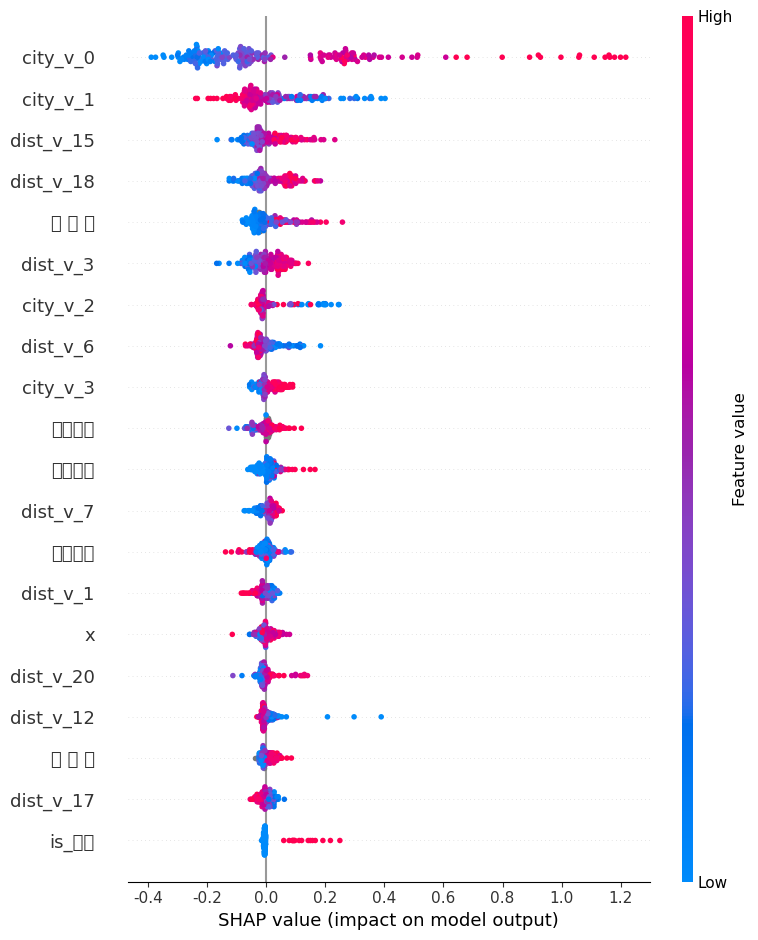

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

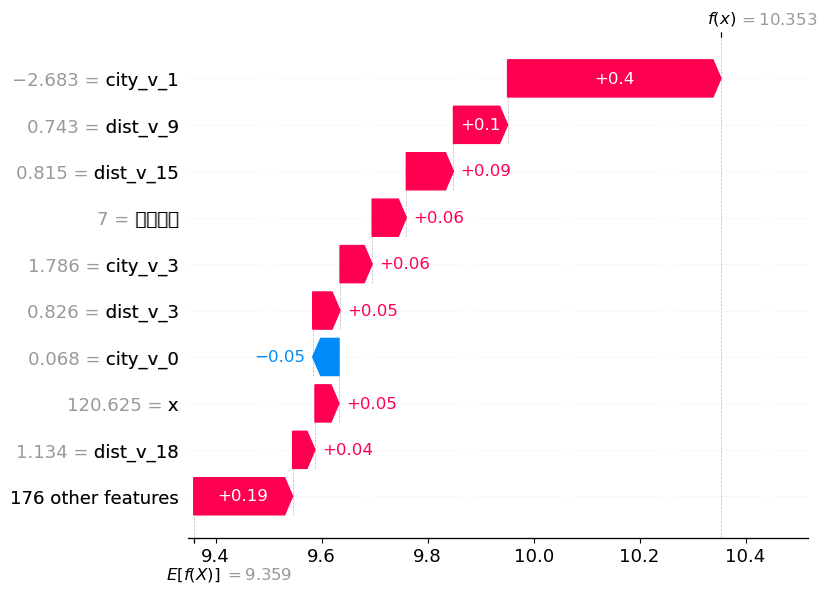

In [ ]:
# admit chinese character in the title
plt.rcParams['font.sans-serif'] = ['SimHei']  # 指定默认字体为黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决保存图像是负号'-'显示为方块的问题

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample)
plt.show()

plt.figure(figsize=(12, 5))
shap.plots.waterfall(shap_values[0])
plt.show()

正在生成 PDP 图...


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
/tmp/ipykernel_307102/3182435016.py:17: UserWarning: Glyph 24314 (\N{CJK UNIFIED IDEOGRAPH-5EFA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_307102/3182435016.py:17: UserWarning: Glyph 31569 (\N{CJK UNIFIED IDEOGRAPH-7B51}) missing

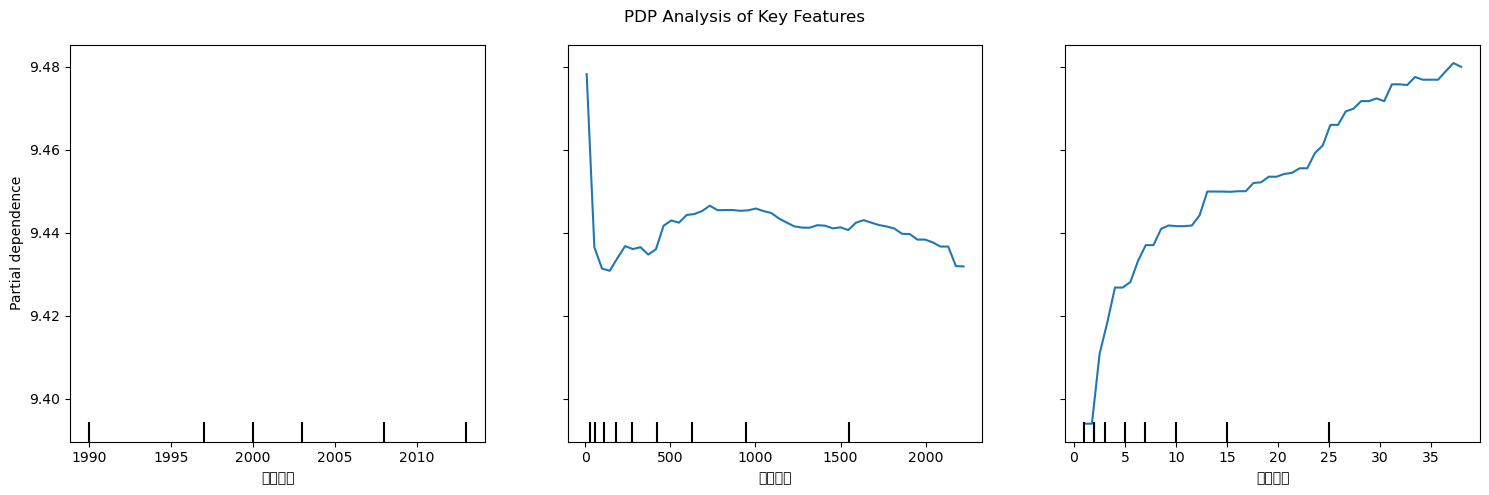

In [ ]:
print("正在生成 PDP 图...")

plt.rcParams['font.sans-serif'] = ['SimHei']  # 指定默认字体为黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决保存图像是负号'-'显示为方块的问题

important_features = X_train.columns[:3].tolist() 

fig, ax = plt.subplots(figsize=(15, 5))
PartialDependenceDisplay.from_estimator(
    trainer.model, 
    X_train, 
    features=important_features, 
    ax=ax,
    grid_resolution=50 
)
plt.suptitle("PDP Analysis of Key Features")
plt.tight_layout()
plt.show()